# Comparison plots
This notebook aims to reproduce most of the plots in the discussion section of [Lochner et al. 2022](https://arxiv.org/abs/2104.05676), making use of the metrics bundle in the csv file produced by the OpSim team. 

**Installation**

The packages required are standard with the exception of `george`, a Gaussian process package, which can be installed with `pip install george`. This is only used for one plot though and could be ignored if you don't want the median internight gap per band plot. I also like to use the `widget` backend for matplotlib which allows more interactive plots. This can be installed with `pip install ipympl`. The line `%matplotlib widget` can simply be commented out if you don't want to use this package.

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import plot_tools
from scipy.interpolate import griddata
import george
from scipy.optimize import minimize

%matplotlib widget

In [42]:
# This just defines the colours and markers to use for the metrics in the plots
metric_colors = {'fom':'C0',
            'lss':'C1',
            'wl':'C2',
            'sn':'C3',
            'sl':'C4',
            'snz':'C5',
            'kn':'C6',
            'pz':'C9'
        }

metric_markers = {'fom':'o',
        'lss':'^',
        'wl':'s',
        'sn':'*',
        'snz':'P',
        'sl':'D',
        'kn':'X',
        'pz':'+'
    }

## Select metrics to plot
We start by selecting which metrics we want to plot and provide shorter display names. In order to convert the metrics correctly for comparison, we need to know if any transforms need to be applied (see Lochner et al. 2022 for futher details). Possibilities include: <br>

invert = $1/x$ <br>
convert_to_flux = $10^{(-x/2.5)}$ <br>
convert_to_precision = $1/x^2$ <br>
one_minus = $1-2x$

In [56]:
# This spreadsheet contains the correct conversions for each metric and standard names for them
metric_names = pd.read_csv('OS_metric_translations.csv', index_col=0)
metric_names.columns

Index(['desc_metric_name', 'desc_metric_display_name', 'maf_metric_v1_5_name',
       'maf_metric_v2_0_name', 'maf_metric_v3_0_name', 'transform_invert',
       'transform_mag_to_flux', 'transform_to_precision',
       'transform_one_minus', 'validated', 'comment'],
      dtype='object')

## Metric files
**Update for v3.x simulations**: The summary files can be found at <br>https://s3df.slac.stanford.edu/data/rubin/sim-data/sims_featureScheduler_runs3.3/maf/summary.h5 and <br> https://s3df.slac.stanford.edu/data/rubin/sim-data/sims_featureScheduler_runs3.4/maf/summary.h5. <br> However the v3.4 file is 1GB and we only use a fraction of these metrics. So I have extracted the required metrics for both v3.3 and v3.4 and placed them in a csv file in the repo (`desc_metrics_summary_v3.4.csv`).

In [57]:
# Where the local copy of the summary file is
analysis_dir = 'FBS_analysis/' 

In [58]:
maf_output_summary_file = analysis_dir + 'desc_metrics_summary_v3.4.csv'
maf_output_full = pd.read_csv(maf_output_summary_file, index_col=0)

In [59]:
maf_columns = []
for idx in metric_names.index:
    maf_columns.append(metric_names.loc[idx, 'maf_metric_v3_0_name'])

In [60]:
maf_output = maf_output_full[maf_columns]

**Missing metrics:** The following simulations are missing at least one metric:

In [61]:
maf_output.index[np.isnan(maf_output).any(axis=1)]

Index(['ddf_acor_sf15_lsf30_lsr10_v3.4_10yrs',
       'ddf_acor_sf15_lsf30_lsr20_v3.4_10yrs',
       'ddf_acor_sf15_lsf40_lsr50_v3.4_10yrs', 'm2_initial_v3.4_10yrs',
       'noroll_mjdp270_v3.4_10yrs', 'roll_pause2_mjdp270_v3.4_10yrs',
       'roll_pause_mjdp270_v3.4_10yrs',
       'roll_uniform_early_half_mjdp67_v3.4_10yrs',
       'roll_uniform_eh_au_acc0.2_mjdp0_v3.4_10yrs',
       'roll_uniform_eh_au_acc1.0_mjdp0_v3.4_10yrs',
       'roll_uniform_mjdp253_v3.4_10yrs', 'start_date_do270v3.4_10yrs',
       'too_combined_no_nss_s10.0_v3.4_10yrs',
       'too_elab_2yr_r128_d2_ugrizy_v3.4_10yrs',
       'too_elab_2yr_r128_d3_ugrizy_v3.4_10yrs',
       'too_elab_2yr_r64_d2_ugrizy_v3.4_10yrs',
       'too_elab_2yr_r64_d3_ugrizy_v3.4_10yrs',
       'too_elab_heavy_r128_d2_ugrizy_v3.4_10yrs',
       'too_elab_heavy_r128_d3_ugrizy_v3.4_10yrs',
       'too_elab_heavy_r32_d2_ugrizy_v3.4_10yrs',
       'too_elab_heavy_r32_d3_ugrizy_v3.4_10yrs',
       'too_elab_heavy_r64_d2_ugrizy_v3.4_10yrs',
 

In [62]:
print(maf_output.shape)
maf_output = maf_output.dropna() # Drop any rows with NaNs
print(maf_output.shape)

(333, 11)
(297, 11)


In [64]:
baseline = 'baseline_v3.4_10yrs'

### Replace the approxmiate MAF SN metric with the DESC one run externally

In [65]:
# sn_metrics_v2 = pd.read_csv(analysis_dir + 'SN_metric_v2.0_2022_07_27.csv', index_col=0)
# sn_metrics_v2_1 = pd.read_csv(analysis_dir + 'SN_metric_v2.1_2022_07_27.csv', index_col=0)
# sn_metrics = pd.concat((sn_metrics_v2, sn_metrics_v2_1))

There's a mismatch between the sims in the MAF summary file and the DESC SN metrics, so we have to restrict the indices

In [66]:
# sn_indices = sn_metrics.index
# maf_indices = maf_output.index
# print(len(sn_indices), len(maf_indices))
# intersection = list(set(sn_indices) & set(maf_indices))
# print(len(intersection))

In [67]:
# maf_output = maf_output.loc[intersection]

In [68]:
# sn_metric_name = metric_names.loc['sn', 'maf_metric_v3_0_name']
# maf_output.loc[intersection, sn_metric_name] = sn_metrics.loc[intersection, 'nsn']

## Compute the metrics relative to baseline
We always compare metrics by subtracting their value at baseline, and then dividing by their value at baseline. So all metrics can be considered as percentage improvement or degradation.

In [69]:
def compute_relative_improvement(metric_series, 
                                 baseline, 
                                 invert=False,
                                 convert_to_flux=False,
                                 convert_to_precision=False,
                                 one_minus=False):
    """
    Calculates the improvement of the metric over the given baseline, including applying the appropriate 
    transforms. Transforms are applied in the same order as used in Lochner et al. so for instance, a value
    will first be converted to flux and then to precision.
    """
    if convert_to_flux:
        metric_series = 10**(-metric_series/2.5)

    if one_minus:
        metric_series = 1 - 2*metric_series

    if invert:
        metric_series = 1/metric_series

    if convert_to_precision:
        metric_series = 1/metric_series**2
        
    baseline_value = metric_series.loc[baseline]
    
    return (metric_series - baseline_value)/baseline_value   

In [70]:
maf_output_rel = maf_output.copy()
for idx in metric_names.index:
    metric = metric_names.loc[idx, 'maf_metric_v3_0_name']
    rel_series = compute_relative_improvement(maf_output[metric], 
                                 baseline,
                                 metric_names.loc[idx, 'transform_invert'], 
                                 metric_names.loc[idx, 'transform_mag_to_flux'],
                                 metric_names.loc[idx, 'transform_to_precision'],
                                 metric_names.loc[idx, 'transform_one_minus'])
    maf_output_rel[metric] = rel_series

At this point, we have 3 important dataframes: <br>
- `metric_names`: contains a key for each metric, its nice display name and the long name in the MAF file
- `maf_output`: the original MAF summary file for all the metrics we care about (i.e. their raw values for each sim)
- `maf_output_rel`: the relative improvement for each metric over baseline, after each metric has been transformed appropriately

## Plotting functions
The functions we will use to make all the plots

### Comparison plot function
Plot many metrics as a function of a specific attribute.

In [71]:
def comparison_plot(metrics_original, metrics_rel, metric_names, x_axis, 
                    probes=[], themes={}, 
                    ylabel='', xlabel='', save_plot=False, savefig_path='', 
                    smoothing='none', nbins=20,
                    plot_baseline=True, baseline_name='baseline_v3.4_10yrs', expand_ylim_by=[1.1, 1.1],
                    figsize=(8,4)):
    """
    Plots a set of metrics against a summary parameter from the simulations (e.g. area, depth, cadence etc.)
    
    Parameters
    ----------
    metrics_original : pd.DataFrame
        The original values for all metrics (columns) for each simulation (row).
    metrics_rel : pd.DataFrame
        The metrics appropriately transformed and expressed as relative improvement over baseline for all 
        metrics (columns) for each simulation (row).
    metric_names: pd.DataFrame
        A translation between what the metric was called in the Lochner et al. paper and its name in the MAF summary file.
    x_axis: string
        Which metric to use on the x-axis
    probes: list of strings
        Which probes to plot, uses the short hand in "metric_names" to translate them. A good base set is 
        ['fom', 'wl', 'sn', 'kn', 'sl']
    themes: dict, optional
        Allows some probes to be plotted with fainter and thinner lines. Provide a dictionary for probes with values of
        either 0 (normal, thick lines) or 1 (fainter, thin lines). Defaults to 0 for all probes.
    ylabel: string, optional
        Label for y axis
    xlabel: string, optional
        Label for x axis
    save_plot: bool, optional
        Whether or not to save the figure to file
    savefig_path: string, optional
        Filename and path for the figure if saving it
    smoothing: string, optional
        Whether to plot all points ('none') or simplify the plot by binning points ('binning'). Generally binning is a
        good idea as there can be hundreds of simulations.
    nbins: int, optional
        Number of bins to use if smoothing='binning'
    plot_baseline: bool, optional
        If true (default), will plot a line with some text indicating the x axis value at baseline
    baseline_name: string, optional
        Which simulation to take as baseline (note this should be the same one used in calculating the relative metric
        values)
    expand_ylim_by: list, optional
        Two values to allow expanding of the y axis to accommodate large legends. E.g. [1.1, 1.4] will expand the top y
        limit of the plot by 40% of the maximum value.
    figsize: tuple, optional
        Matplotlib figsize
    """

    # sim_annotation_numbers = {
    #     'footprint_big_sky_dustv1.5_10yrs': 1,
    #     'footprint_newAv1.5_10yrs' : 2,
    # }
    
    
    
    t0 = {'lw':2, 'alpha':1}
    t1 = {'lw':1, 'alpha':0.8}

    themes_translations = {0:t0, 1:t1}
    
    if len(list(themes.keys())) == 0:
        for p in probes:
            themes[p] = 0

    x_axis_metric = metric_names.loc[x_axis, 'maf_metric_v3_0_name']
    xvals = metrics_original.loc[metrics_rel.index, x_axis_metric].astype('float')
    inds = np.argsort(xvals)

    plt.figure(figsize=figsize)
    

    ylim = [0,0]

    for i in range(len(probes)):
        metric = metric_names.loc[probes[i], 'maf_metric_v3_0_name']

        yvals = metrics_rel.loc[metrics_rel.index, metric].astype('float')

        x = xvals.iloc[inds].values
        y = yvals.iloc[inds].values

        unique_x = np.unique(x)
        unique_y = np.zeros(len(unique_x))

        for k in range(len(unique_x)):
            msk = x == unique_x[k]
            if sum(msk) == 1:
                unique_y[k] = y[msk][0]
            else:
                unique_y[k] = y[msk].mean()

        x = unique_x
        y = unique_y

        if smoothing == 'none':
            new_x = x
            new_y = y
            yerr = np.zeros(len(new_x))

        elif smoothing == 'binning':
            xgrid = np.linspace(x.min(), x.max(), nbins)
            x_delt = xgrid[1] - xgrid[0]
            new_x = []
            new_y = []
            yerr = []

            for k in range(len(xgrid)):
                msk = (x>=xgrid[k]) & (x<xgrid[k] + x_delt)
                if msk.sum() == 0:
                    pass
                elif msk.sum() == 1:
                    new_x.append(x[msk][0])
                    new_y.append(y[msk][0])
                    yerr.append(0)
                else:
                    new_x.append(x[msk].mean())
                    new_y.append(y[msk].mean())
                    yerr.append(y[msk].std())

            new_x = np.array(new_x)
            new_y = np.array(new_y)
            yerr = np.array(yerr)
            

        theme = themes_translations[themes[probes[i]]]
        plt.errorbar(new_x, new_y, yerr=yerr, marker=None,
                  lw=theme['lw'], alpha=theme['alpha'], 
                 color=metric_colors[probes[i]])
        plt.plot(new_x, new_y, marker=metric_markers[probes[i]],
                 label=metric_names.loc[probes[i], 'desc_metric_display_name'], lw=0,
                 linestyle=None, alpha=theme['alpha'], color=metric_colors[probes[i]])

        if (new_y+yerr).max() > ylim[1]:
            ylim[1] = (new_y+yerr).max()
        if (new_y-yerr).min() < ylim[0]:
            ylim[0] = (new_y-yerr).min()
        
###############################################################################################
        # Relic code to apply annotations to the plot. Left in just in case we need it again.
#     if len(annotations) != 0:
#         anno_x = []
#         anno_y = []
#         anno_sim = []
#         anno_num = []
#         for k in annotations.keys():
#             which_probe = annotations[k][0]
#             metric = probes_translations[which_probe]
#             yshift = -0.06 + annotations[k][1]
#             xtext = misc_metrics.loc[k, x_axis].astype('float')
#             ytext = metrics_rel.loc[k, metric].astype('float') + yshift
#             anno_x.append(xtext)
#             anno_y.append(ytext)
#             anno_sim.append(k)
#             anno_num.append(sim_annotation_numbers[k])

#         sorted_inds = np.argsort(anno_x)
#         counter = 1
#         print_str = 'Annotations: '
#         for ind in sorted_inds:
#             plt.text(anno_x[ind], anno_y[ind], (str)(counter), color='k')
#             # plt.text(anno_x[ind], anno_y[ind], (str)(anno_num[ind]), color='k')
#             sim_name = anno_sim[ind]
#             sim_name = sim_name.replace('_', '\_')
#             print_str += '%d-\\texttt{%s}, ' %(counter, sim_name)
#             # print_str += '%d-\\texttt{%s}, ' %(anno_num[ind], sim_name)
#             counter += 1
#         print(print_str[:-2]) 

    # handles, labels = plt.gca().get_legend_handles_labels()
    # # remove the errorbars
    # print(handles[0][0])
    # handles = [h[0] for h in handles]
    # print(handles[0])
 
    # plt.legend(handles, labels, numpoints=1, loc='best')
###############################################################################################
    plt.legend(loc='best')
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    

    ax = plt.gca()
    new_ylim = [ylim[0]*expand_ylim_by[0], ylim[1]*expand_ylim_by[1]]
    new_xlim = ax.get_xlim()
    
   
    zo = 0

    plt.plot(new_xlim, [0, 0], '--k', alpha=0.5, zorder=zo)

    if plot_baseline:

        base_val = float(metrics_original.loc[baseline_name, x_axis_metric])
        plt.plot([base_val, base_val], new_ylim, '--k', lw=1, alpha=0.3,
                 zorder=zo)
        plt.text(base_val, new_ylim[1]*0.8, 'baseline', 
                alpha=0.3, zorder=zo)


    plt.xlim(new_xlim)
    plt.ylim(new_ylim)
    plt.tight_layout()
    
    if len(savefig_path) != 0 and save_plot:
        plt.savefig(savefig_path)

### Individual sims plot function
Function to plot a set of simulations for some metrics

In [130]:
def plot_individual_sims(metrics_rel, metric_names, list_of_sims, probes=[], ylabel='', xlabel='',
                         save_plot=False, savefig_path='', expand_ylim_by=[1.1, 1.1],
                         legend_outside=False, figsize=(8,4), plot_vertical=False):
    """
    Plots the relative metrics for a subset of simulations.
    
    Parameters
    ----------
    metrics_rel : pd.DataFrame
        The metrics appropriately transformed and expressed as relative improvement over baseline for all 
        metrics (columns) for each simulation (row).
    metric_names: pd.DataFrame
        A translation between what the metric was called in the Lochner et al. paper and its name in the MAF summary file.
    list_of_sims: list of strings
        Which simulations to plot on the x axis. Note this should be a short list to maintain readability.
    probes: list of strings
        Which probes to plot, uses the short hand in "metric_names" to translate them. A good base set is 
         ['fom', 'wl', 'sn', 'kn', 'sl']
    ylabel: string, optional
        Label for y axis
    xlabel: string, optional
        Label for x axis
    save_plot: bool, optional
        Whether or not to save the figure to file
    savefig_path: string, optional
        Filename and path for the figure if saving it
    expand_ylim_by: list, optional
        Two values to allow expanding of the y axis to accommodate large legends. E.g. [1.1, 1.4] will expand the top y
        limit of the plot by 40% of the maximum value.
    legend_outside: bool, optional
        If true, will place the legend outside the plot area. The figure size may need to be adjusted.
    figsize: tuple, optional
        Matplotlib figsize
    plot_vertical: boolean, optional
        If true, will flip the axes so the simulations are on the y-axis.
        
    """
                         
    plt.figure(figsize=figsize)
    x = np.arange(len(list_of_sims))
    xlim = [-0.1, len(x)-1+0.1]
    if plot_vertical:
        plt.plot([0]*len(xlim), xlim, 'k--', alpha=0.5)
    else:
        plt.plot(xlim, [0]*len(xlim), 'k--', alpha=0.5)
    
    for p in probes:
        metric = metric_names.loc[p, 'maf_metric_v3_0_name']
        y = metrics_rel.loc[list_of_sims, metric].astype('float')
        if plot_vertical:
            plt.plot(y, x, label=metric_names.loc[p, 'desc_metric_display_name'], 
                 color=metric_colors[p], marker=metric_markers[p])
        else:
            plt.plot(x, y, label=metric_names.loc[p, 'desc_metric_display_name'], 
                 color=metric_colors[p], marker=metric_markers[p])
        
    
    if legend_outside:
        plt.legend(bbox_to_anchor=(1.1, 1.00))
    else:
        plt.legend()
    
    ax = plt.gca()
    if plot_vertical:
        plt.yticks(x, list_of_sims)
        plt.ylabel(xlabel)
        plt.xlabel(ylabel)
        ylim = ax.get_xlim()
        new_ylim = [ylim[0]*expand_ylim_by[0], ylim[1]*expand_ylim_by[1]]
        plt.xlim(new_ylim)
        plt.ylim(xlim)
    else:
        plt.xticks(x, list_of_sims, rotation=90)
        plt.xlabel(xlabel)
        plt.ylabel(ylabel)
        ylim = ax.get_ylim()
        new_ylim = [ylim[0]*expand_ylim_by[0], ylim[1]*expand_ylim_by[1]]
        plt.ylim(new_ylim)
        plt.xlim(xlim)
    plt.tight_layout()

    if len(savefig_path) != 0 and save_plot:
        plt.savefig(savefig_path)

### Convenience function to get a metric's full name
It's a bit long-winded to get the actual MAF name of the metric corresponding to, for instance, area. This little function makes it a bit easier.

In [73]:
def get_full_metric_name(metric, metric_names_df):
    """
    Convenience function to return the full MAF metric name corresponding to a shorthand like 'area' or 'depth'.
    
    Parameters
    ----------
    metric: str
        The shorthand for the metric. Must correspond to an item in the index of metric_names_df.
    metric_names_df: pd.DataFrame
        The dataframe containing details about the metric names (generally referred to as `metric_names` in this notebook).
    """
    return metric_names_df.loc[metric, 'maf_metric_v3_0_name']

In [74]:
# Standard set of probes to plot metrics for
probes_to_plot = ['fom', 'wl', 'sl', 'sn', 'kn']
y_label = '(metric - baseline)/baseline'

## Metric comparison plots
These are the plots used to draw general insights about observing strategy in Lochner et al. (2022). The plot the various metrics as a function of properties of the survey such as effective area and depth. There are also plots analysing specific families of simulations to better understand qualitative effects such as the impact of changing the filter distributions.

### Baseline evoluation over the years

The baseline has been adjusted over the years, representing significant improvements to most metrics which we can see in this plot.

In [75]:
baseline_sims = [idx for idx in maf_output.index if 'baseline' in idx]
baseline_sims.insert(0, baseline_sims.pop(-2))
baseline_sims.insert(7, baseline_sims.pop(-1))

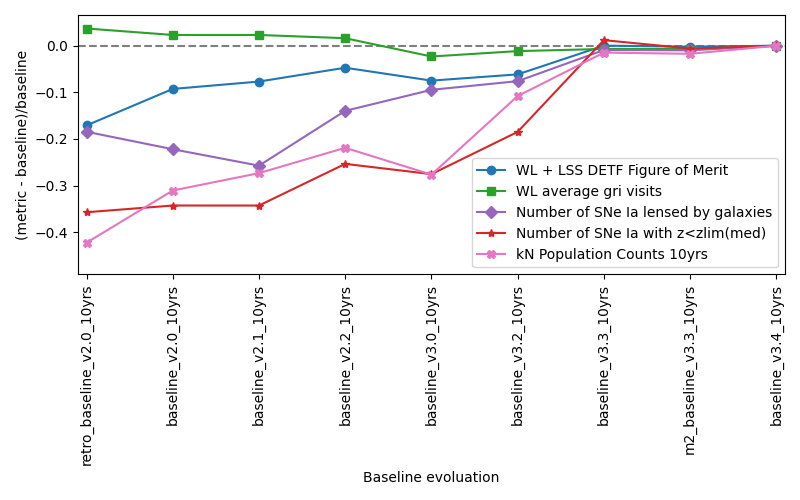

In [76]:
plot_individual_sims(maf_output_rel, metric_names, baseline_sims, probes=probes_to_plot, ylabel=y_label, 
                     xlabel = 'Baseline evoluation', expand_ylim_by=[1.1, 1.1], figsize=(8,5), 
                     legend_outside=False)

Now we can drop the older baseline sims and just keep v3.4

In [77]:
baseline_sims.pop(-1)

'baseline_v3.4_10yrs'

In [78]:
inds = maf_output.index[~np.in1d(maf_output.index, baseline_sims)]
maf_output = maf_output.loc[inds]
maf_output_rel = maf_output_rel.loc[inds]

### The effect of weather

This round of simulations includes different weather variants to get a handle on the variance of each metric.

In [79]:
mn = np.zeros(len(probes_to_plot))
min_vals = np.zeros(len(probes_to_plot))
max_vals = np.zeros(len(probes_to_plot))
weather_sims_mask = maf_output_rel.index.str.contains('weather')
this_df = maf_output_rel[weather_sims_mask]
for i in range(len(probes_to_plot)):
    maf_name = get_full_metric_name(probes_to_plot[i], metric_names)
    vals = this_df[maf_name]
    mn[i] = np.mean(vals)
    min_vals[i] = np.min(vals)
    max_vals[i] = np.max(vals)

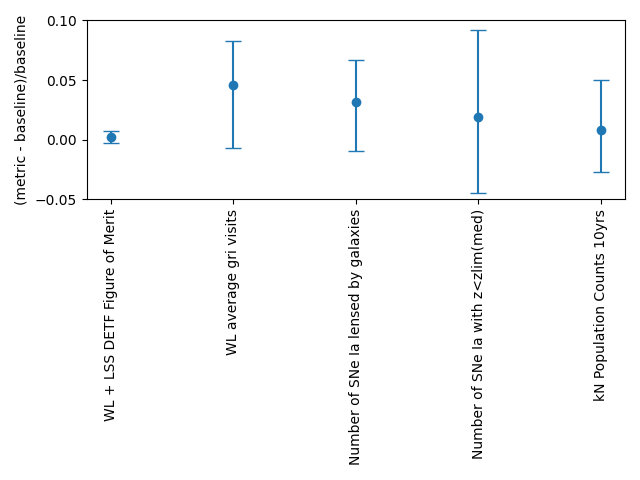

In [80]:
plt.figure()
xvals = np.arange(len(probes_to_plot))
plt.errorbar(xvals, mn, yerr=np.vstack((mn-min_vals, max_vals-mn)),
             linestyle='none', marker='o', capsize=6)
ax = plt.gca()
ax.set_xticks(xvals, metric_names.loc[probes_to_plot, 'desc_metric_display_name'], rotation=90);
plt.ylabel(y_label)
plt.ylim([-0.05,0.1])
plt.tight_layout()

It seems appropriate to drop the weather sims for the remainder of the analysis

In [81]:
inds = maf_output.index[~weather_sims_mask]
maf_output = maf_output.loc[inds]
maf_output_rel = maf_output_rel.loc[inds]

### Area

Reproduces Fig. 8 of Lochner et al. (2022).

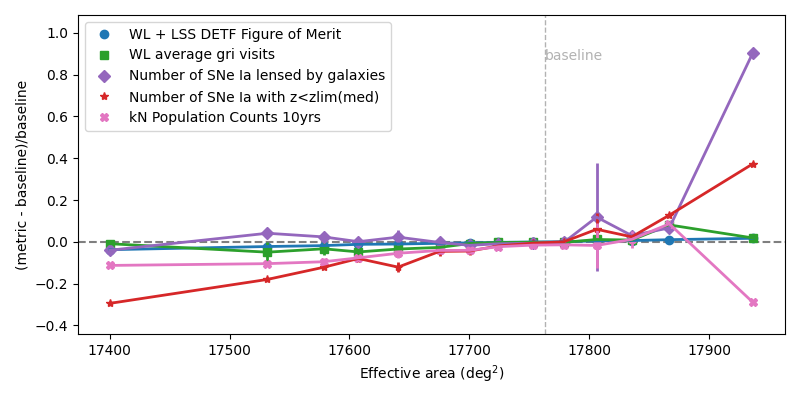

In [83]:
comparison_plot(maf_output, maf_output_rel, metric_names, 'area', probes=probes_to_plot, 
                smoothing='binning',
               expand_ylim_by=[1.5, 1.2], xlabel='Effective area (deg$^2$)', ylabel=y_label,
               figsize=(8,4))

**Curious about which simulations have so much area but poor performance?** 

Here's how you can access the raw numbers to check which simulations drive this behaviour. Remember though, the points on the plots are averaged and don't refer to specific simulations, although it's usually a family of simulations driving the behaviour.

In [84]:
x_axis_metric = get_full_metric_name('area', metric_names)
maf_output.loc[maf_output_rel.index, x_axis_metric].sort_values()

rolling_phased_ps_182_psf_91_v3.3_10yrs             17400.235853
internal_u_expt60_nscale1.5v3.4_10yrs               17525.290606
rolling_phased_ps1_-91_ps2_91_ps3_273_v3.3_10yrs    17537.880010
internal_u_expt45_nscale1.5v3.4_10yrs               17577.326812
rolling_phased_ps_182_psf_-91_v3.3_10yrs            17579.844693
                                                        ...     
ddf_loaded_fl2_v3.4_10yrs                           17829.114905
noroll_v3.4_10yrs                                   17830.793493
noroll_mjdp365_v3.4_10yrs                           17846.740072
onesnap_v3.4_10yrs                                  17866.883119
no_pairs_noroll_v3.4_10yrs                          17936.544492
Name: Effective Area (deg) Exgalm5WithCuts i band non-DD year 10 HealpixSlicer, Length: 257, dtype: float64

### Median i-band depth in effective area

Reproduces Fig. 9 of Lochner et al. (2022).

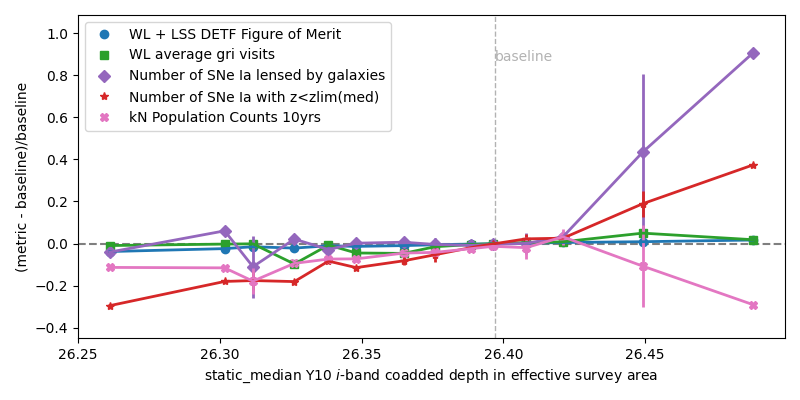

In [85]:
comparison_plot(maf_output, maf_output_rel, metric_names, 'depth', probes=probes_to_plot, smoothing='binning',
               expand_ylim_by=[1.5, 1.2], xlabel='static_median Y10 $i$-band coadded depth in effective survey area', 
               ylabel=y_label)

In [86]:
x_axis_metric = get_full_metric_name('depth', metric_names)
maf_output.loc[maf_output_rel.index, x_axis_metric].sort_values()

rolling_phased_ps_182_psf_91_v3.3_10yrs             26.261184
rolling_phased_ps1_-91_ps2_91_ps3_273_v3.3_10yrs    26.301656
rolling_phased_ps_182_psf_-91_v3.3_10yrs            26.309783
octo_v3.4_10yrs                                     26.313508
internal_u_expt60_nscale1.5v3.4_10yrs               26.326262
                                                      ...    
noroll_v3.4_10yrs                                   26.423908
noroll_mjdp365_v3.4_10yrs                           26.424927
onesnap_v3.4_10yrs                                  26.447892
no_pairs_v3.4_10yrs                                 26.450523
no_pairs_noroll_v3.4_10yrs                          26.488044
Name: Median Exgalm5WithCuts i band non-DD year 10 HealpixSlicer, Length: 257, dtype: float64

It seems the `no_pairs` runs dramatically improve the SNSL metric.

### Combined metric

Reproduces Fig. 10 of Lochner et al. (2022).

In [87]:
def calculate_combined_metric(metrics_rel):
    """
    Very simple approximation to combining the SN and FoM metrics from Lochner et al. 2022.
    
    Parameters
    ----------
    metrics_rel: pd.DataFrame
        Dataframe containing all the metrics relative to baseline.
    """
    frac_static = 0.5
    frac_sn = 0.5
    
    sn = metrics_rel[metric_names.loc['sn', 'maf_metric_v3_0_name']]
    fom = metrics_rel[metric_names.loc['fom', 'maf_metric_v3_0_name']]
    
    return frac_static*fom + frac_sn*sn

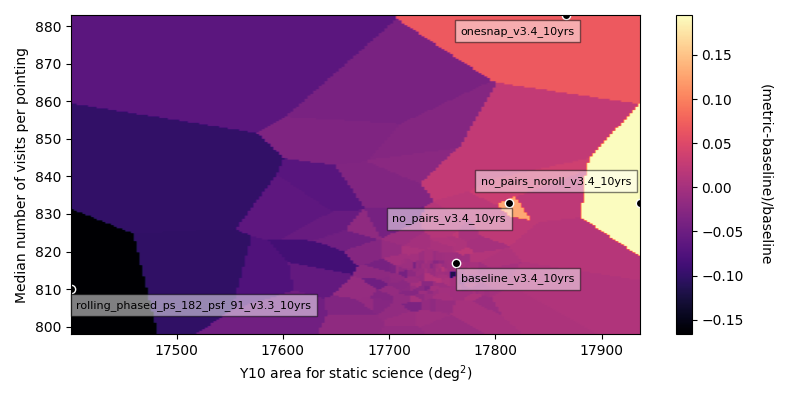

In [88]:
combined_metric = calculate_combined_metric(maf_output_rel)
maf_output_rel['combined'] = combined_metric

# We use the WL metric since it's the median number of visits.
xaxis = 'area'
yaxis = 'nvis'

xaxis_metric = metric_names.loc[xaxis, 'maf_metric_v3_0_name']
yaxis_metric = metric_names.loc[yaxis, 'maf_metric_v3_0_name']
# maf_output.loc[maf_output_rel.index, metric_names.loc['depth', 'maf_metric_v3_0_name']]

X = np.array([maf_output.loc[maf_output_rel.index, xaxis_metric],
              maf_output.loc[maf_output_rel.index, yaxis_metric]
             ]).T
Z = np.array(maf_output_rel.combined)

xmin = X[:,0].min()
xmax = X[:,0].max()
ymin = X[:,1].min()
ymax = X[:,1].max()


extent = xmin, xmax, ymin, ymax

X[:,0] = (X[:,0] - xmin)/(xmax-xmin)
X[:,1] = (X[:,1] - ymin)/(ymax-ymin)

# These are some specific selected simulations to mark. You can choose different ones but note that getting the label
# positions right requires some fiddling (xshift and yshift below).
labels = [
         'no_pairs_noroll_v3.4_10yrs',
         'no_pairs_v3.4_10yrs',
         'onesnap_v3.4_10yrs',
         baseline,
         'rolling_phased_ps_182_psf_91_v3.3_10yrs',
        
         ]

xlabs = []
ylabs = []


xshift = [5]*len(labels)
xshift[0] = -150
xshift[1] = -110
xshift[2] = -100


yshift = [-5]*len(labels)
yshift[0] = 5


    

plt.close('all')
x = np.linspace(X[:,0].min(), X[:,0].max(), 200)
y = np.linspace(X[:,1].min(), X[:,1].max(), 200)
xgrid, ygrid = np.meshgrid(x, y)
zgrid = griddata(X, Z, (xgrid, ygrid), method='nearest')

plt.figure(figsize=(8,4))

for i in range(len(labels)):
    l = labels[i]
    xlab = maf_output.loc[l, xaxis_metric]
    ylab = maf_output.loc[l, yaxis_metric]

    xlabs.append(xlab)
    ylabs.append(ylab)
    
    plt.plot(xlabs[i], ylabs[i], 'ok', markeredgecolor='w')
    ind = labels[i]+'.db'
    this_text = labels[i]
    plt.text(xlabs[i]+xshift[i], ylabs[i]+yshift[i], this_text, usetex=False, 
             fontsize=8,bbox=dict(facecolor='white', alpha=0.5))

im1=plt.imshow(zgrid, origin='lower', extent=extent, aspect='auto', cmap='magma')
plt.plot([])
cbar = plt.colorbar()
cbar.set_label('(metric-baseline)/baseline', rotation=-90, labelpad=20)

plt.xlabel(metric_names.loc[xaxis, 'desc_metric_display_name'])
plt.ylabel(metric_names.loc[yaxis, 'desc_metric_display_name'])
plt.tight_layout()

In [89]:
maf_output_rel.sort_values('combined')

,3x2ptFoM Exgalm5WithCuts i band non-DD year 10 HealpixSlicer,Median WeakLensingNvisits gri band non-DD HealpixSlicer,Total detected SNNSNMetric_reducen_sn DDF excluded HealpixSlicer,Total detected SNSLMetric HealpixSlicer,Total detected KNePopMetric_all_multi_color_detect all models UserPointsSlicer,Effective Area (deg) Exgalm5WithCuts i band non-DD year 10 HealpixSlicer,Median Exgalm5WithCuts i band non-DD year 10 HealpixSlicer,Median Median Inter-Night Gap WFD all bands HealpixSubsetSlicer,Median Median Inter-Night Gap WFD r band HealpixSubsetSlicer,Mean Median Season Length WFD all bands HealpixSubsetSlicer,fONv MedianNvis fO HealpixSlicer,combined
rolling_phased_ps_182_psf_91_v3.3_10yrs,-0.037711,-0.009238,-0.294692,-0.040213,-0.113147,-0.020412,-0.221389,0.033015,0.171792,0.211217,0.0,-0.166202
octo_v3.4_10yrs,-0.009658,0.000000,-0.221282,-0.256772,-0.241268,-0.000095,-0.142607,0.021244,-0.172984,-0.075864,0.0,-0.115470
rolling_phased_ps1_-91_ps2_91_ps3_273_v3.3_10yrs,-0.023874,-0.002309,-0.179914,0.060564,-0.115292,-0.012663,-0.161123,-0.285335,-0.152541,-0.025892,0.0,-0.101894
internal_u_expt60_nscale1.5v3.4_10yrs,-0.021320,-0.096998,-0.180446,0.021434,-0.093881,-0.013372,-0.122226,-0.004665,0.172534,0.004011,0.0,-0.100883
roll_uniform_eh_acc1.0_mjdp0_v3.4_10yrs,-0.009167,0.002309,-0.164541,0.090203,-0.071956,-0.006710,-0.045577,-0.298937,-0.210739,-0.114282,0.0,-0.086854
...,...,...,...,...,...,...,...,...,...,...,...,...
ddf_loaded_half_fl1_v3.3_10yrs,0.003635,0.020785,0.060384,0.018994,-0.004891,0.002504,0.023935,-0.043892,0.000567,0.010035,0.0,0.032010
ddf_loaded_fl1_v3.3_10yrs,0.005203,0.025404,0.066124,0.019610,0.011070,0.003260,0.040909,-0.036268,-0.001052,0.007256,0.0,0.035664
onesnap_v3.4_10yrs,0.010218,0.080831,0.127613,0.066680,0.086115,0.005859,0.098215,-0.153133,-0.153847,0.013582,0.0,0.068916
no_pairs_v3.4_10yrs,0.007750,0.018476,0.251524,0.803347,-0.300395,0.002835,0.103550,-0.340588,0.182704,0.098584,0.0,0.129637


### Median inter-night gap all bands

This plot attempts to reproduce Fig. 14 of Lochner et al. (2022). For these simulations, there's very little variance with the exception of the `no_pairs` simulation.

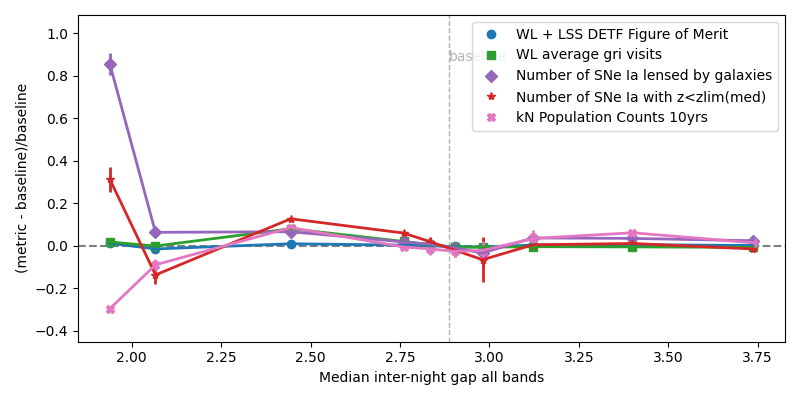

In [90]:
comparison_plot(maf_output, maf_output_rel, metric_names, 'internight_gap', probes=probes_to_plot, smoothing='binning',
               expand_ylim_by=[1.5, 1.2], xlabel='Median inter-night gap all bands', ylabel=y_label)

In [101]:
x_axis_metric = get_full_metric_name('internight_gap', metric_names)
maf_output.loc[maf_output_rel.index, x_axis_metric].sort_values()[:10]

no_pairs_v3.4_10yrs                                    1.903633
no_pairs_noroll_v3.4_10yrs                             1.974909
roll_uniform_early_half_accordion1_mjdp0_v3.4_10yrs    2.023872
roll_uniform_eh_acc1.0_mjdp0_v3.4_10yrs                2.023872
rolling_phased_ps1_-91_ps2_91_ps3_273_v3.3_10yrs       2.063139
rolling_phased_ps_182_psf_-91_v3.3_10yrs               2.088084
roll_uniform_eh_acc0.8_mjdp0_v3.4_10yrs                2.091353
onesnap_v3.4_10yrs                                     2.444789
ddf_loaded_half_fl1_v3.3_10yrs                         2.760153
ddf_loaded_half_fl1_v3.4_10yrs                         2.776460
Name: Median Median Inter-Night Gap WFD all bands HealpixSubsetSlicer, dtype: float64

### Median inter-night gap per band

Reproduces Fig. 15 of Lochner et al. (2022).

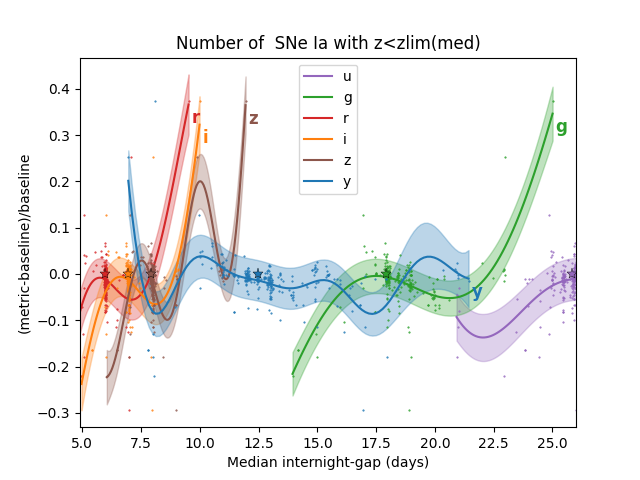

In [103]:
bands = ['u','g','r','i','z','y']
cols = ['C4', 'C2', 'C3', 'C1', 'C5', 'C0']
normalise_x = False
# which_metric = 'kn_Pop_kNe_counts'
which_metric = metric_names.loc['sn', 'maf_metric_v3_0_name']
# which_metric = 'static_median Y10 $i$-band coadded depth in effective survey area'
# which_metric = 'pz_y10_zlow_stdd'
# which_metric = 'sl_num_lensed_SNe_Ia_with_good_time_delays_lensed_by_galaxies'
# which_metric = 'fONv MedianNvis fO All visits HealpixSlicer'

        
# col = 'fONv MedianNvis fO All visits HealpixSlicer'
# inds = misc_metrics.loc[inds][(misc_metrics.loc[inds, col]<=1000)&(misc_metrics.loc[inds, col]>=900)].index

k = 0
plt.figure()
for b in bands:
    x_axis = metric_names.loc['internight_gap_filter', 'maf_metric_v3_0_name'].replace('r band', f'{b} band')
    
    x = maf_output_full.loc[maf_output_rel.index, x_axis]
    if normalise_x:
        x = (x-x.min())/(x.max()-x.min())
    y = maf_output_rel[which_metric]

    kernel = george.kernels.ExpSquaredKernel((x.max()-x.min()))

    gp = george.GP(kernel, fit_mean=True, fit_white_noise=True)
    gp.compute(x, y.std())

    def neg_ln_like(p):
            gp.set_parameter_vector(p)
            return -gp.log_likelihood(y)

    def grad_neg_ln_like(p):
        gp.set_parameter_vector(p)
        return -gp.grad_log_likelihood(y)

    result = minimize(neg_ln_like, gp.get_parameter_vector(),
                              jac=grad_neg_ln_like, method="L-BFGS-B",
                              tol = 1e-5)
    gp.set_parameter_vector(result.x)

    pred_x = np.linspace(x.min(), x.max(), 100)
    pred_y, y_var = gp.predict(y, pred_x, return_var=True)
    other_pred_y = gp.predict(y, x, return_cov=False)
    
    new_x = pred_x
    new_y = pred_y
    
    y_err = np.sqrt(y_var+(y-other_pred_y).std()**2)
    
    baseline_x = maf_output_full.loc[baseline,x_axis]
    baseline_y = 0

    if not normalise_x:
        plt.fill_between(new_x, new_y-y_err, new_y+y_err, color=cols[k], alpha=0.3)
    plt.plot(new_x, new_y, color=cols[k], label=b)
    
    plt.plot(x, y, '.', markersize=1, color=cols[k]
        )
    plt.plot(baseline_x, baseline_y, '*', markersize=8, 
             markerfacecolor=cols[k], markeredgecolor='k', markeredgewidth=0.3)
    plt.text(new_x.max()+0.1, new_y[new_x.argmax()]-0.04, '$\mathbf{%s}$' %b, color=cols[k], fontsize=12)
    k+=1
plt.xlabel('Median internight-gap (days)')
plt.ylabel('(metric-baseline)/baseline')
plt.title('Number of  SNe Ia with z<zlim(med)')
plt.legend()
if not normalise_x:
    plt.xlim([4.9,26])


There's too much variance to draw strong conclusions here

### Cumulative season length

This is supposed to reproduce Fig. 16 of Lochner et al. (2022), but unfortunately we don't have the actual cumulative season length anymore. I have substituted with the mean season length, but this is not quite the same quantity and could be impacted by things like rolling cadence so it's likely this plot is not quite as useful as the previous version.

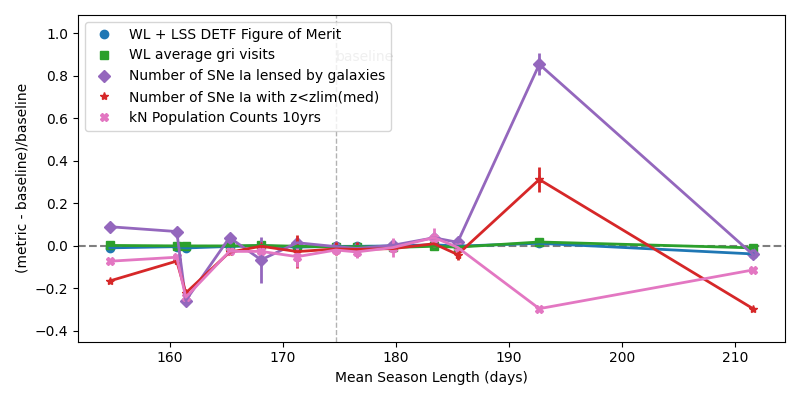

In [104]:
comparison_plot(maf_output, maf_output_rel, metric_names, 'season_length', probes=probes_to_plot, smoothing='binning',
               expand_ylim_by=[1.5, 1.2], xlabel='Mean Season Length (days)', ylabel=y_label)

In [111]:
x_axis_metric = get_full_metric_name('season_length', metric_names)
maf_output.loc[maf_output_rel.index, x_axis_metric].sort_values()[-10:]

noroll_mjdp0_v3.4_10yrs                    182.553371
noroll_mjdp365_v3.4_10yrs                  183.019250
noroll_v3.3_10yrs                          183.762279
noroll_v3.4_10yrs                          184.235451
noroll_mjdp180_v3.4_10yrs                  185.369768
rolling_phased_ps_-182_v3.3_10yrs          185.591687
rolling_phased_ps_-182_psf_0_v3.3_10yrs    185.591687
no_pairs_v3.4_10yrs                        191.917042
no_pairs_noroll_v3.4_10yrs                 193.494486
rolling_phased_ps_182_psf_91_v3.3_10yrs    211.593474
Name: Mean Median Season Length WFD all bands HealpixSubsetSlicer, dtype: float64

## Specific families of simulations

### Variations in u-band exposure

/tmp/ipykernel_6368/2191849380.py:80: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


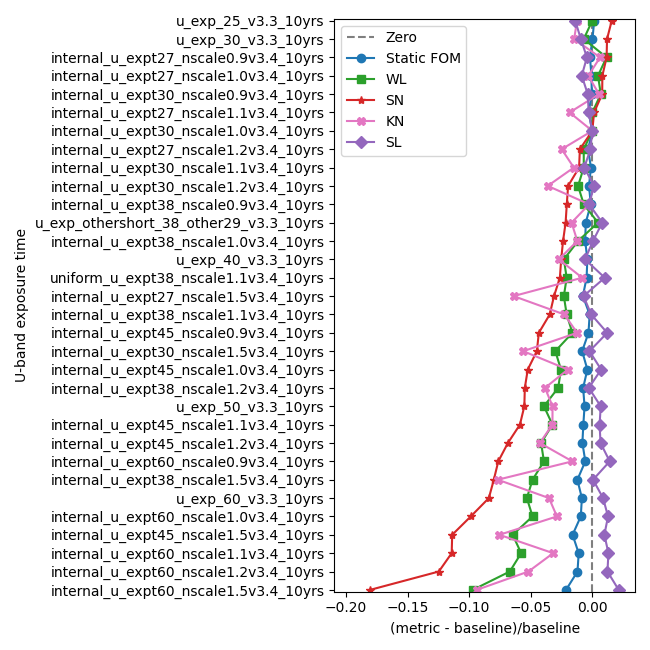

In [148]:
list_of_sims = maf_output.index[maf_output.index.str.contains('u_exp')]
# The SN metric tends to be the most sensitive so we order by that for readability
sn_metric = get_full_metric_name('sn', metric_names)
list_of_sims = maf_output_rel.loc[list_of_sims].sort_values(sn_metric).index

probes = ['fom', 'wl', 'sn', 'kn', 'sl']

plot_individual_sims(maf_output_rel, metric_names, list_of_sims, probes=probes, ylabel=y_label, 
                     xlabel = 'U-band exposure time', expand_ylim_by=[1.1, 1.1], figsize=(6.5,6.5), 
                     legend_outside=True, plot_vertical=True)
plt.gca().get_legend().set_visible(False)
plt.tight_layout()
plt.legend(['Zero', 'Static FOM', 'WL', 'SN', 'KN', 'SL'], loc='upper left')

### Rolling cadence

In [186]:
maf_output_rel.loc[list_of_sims]

,3x2ptFoM Exgalm5WithCuts i band non-DD year 10 HealpixSlicer,Median WeakLensingNvisits gri band non-DD HealpixSlicer,Total detected SNNSNMetric_reducen_sn DDF excluded HealpixSlicer,Total detected SNSLMetric HealpixSlicer,Total detected KNePopMetric_all_multi_color_detect all models UserPointsSlicer,Effective Area (deg) Exgalm5WithCuts i band non-DD year 10 HealpixSlicer,Median Exgalm5WithCuts i band non-DD year 10 HealpixSlicer,Median Median Inter-Night Gap WFD all bands HealpixSubsetSlicer,Median Median Inter-Night Gap WFD r band HealpixSubsetSlicer,Mean Median Season Length WFD all bands HealpixSubsetSlicer,fONv MedianNvis fO HealpixSlicer,combined
rolling_phased_ps_182_psf_91_v3.3_10yrs,-0.037711,-0.009238,-0.294692,-0.040213,-0.113147,-0.020412,-0.221389,0.033015,0.171792,0.211217,0.0,-0.166202
rolling_phased_ps1_-91_ps2_91_ps3_273_v3.3_10yrs,-0.023874,-0.002309,-0.179914,0.060564,-0.115292,-0.012663,-0.161123,-0.285335,-0.152541,-0.025892,0.0,-0.101894
roll_uniform_eh_acc1.0_mjdp0_v3.4_10yrs,-0.009167,0.002309,-0.164541,0.090203,-0.071956,-0.006710,-0.045577,-0.298937,-0.210739,-0.114282,0.0,-0.086854
roll_uniform_early_half_accordion1_mjdp0_v3.4_10yrs,-0.009167,0.002309,-0.164541,0.090203,-0.071956,-0.006710,-0.045577,-0.298937,-0.210739,-0.114282,0.0,-0.086854
rolling_phased_ps_182_psf_-91_v3.3_10yrs,-0.020381,-0.002309,-0.129908,0.037196,-0.115507,-0.010301,-0.148471,-0.276694,-0.157428,-0.011142,0.0,-0.075144
rolling_phased_ps_182_v3.3_10yrs,-0.010344,-0.006928,-0.083251,-0.028208,-0.073415,-0.003875,-0.102547,0.007221,0.002281,0.022196,0.0,-0.046797
rolling_phased_ps_182_psf_0_v3.3_10yrs,-0.010344,-0.006928,-0.083251,-0.028208,-0.073415,-0.003875,-0.102547,0.007221,0.002281,0.022196,0.0,-0.046797
roll_uniform_eh_acc0.8_mjdp0_v3.4_10yrs,-0.003501,0.000000,-0.071419,0.067575,-0.053162,-0.002221,-0.023990,-0.275562,-0.164938,-0.080457,0.0,-0.037460
rolling_phased_ps_-182_psf_0_v3.3_10yrs,-0.004060,-0.004619,-0.066811,0.009629,-0.028533,-0.001654,-0.041816,0.030351,0.170848,0.062376,0.0,-0.035435
rolling_phased_ps_-182_v3.3_10yrs,-0.004060,-0.004619,-0.066811,0.009629,-0.028533,-0.001654,-0.041816,0.030351,0.170848,0.062376,0.0,-0.035435


/tmp/ipykernel_6368/2191849380.py:80: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


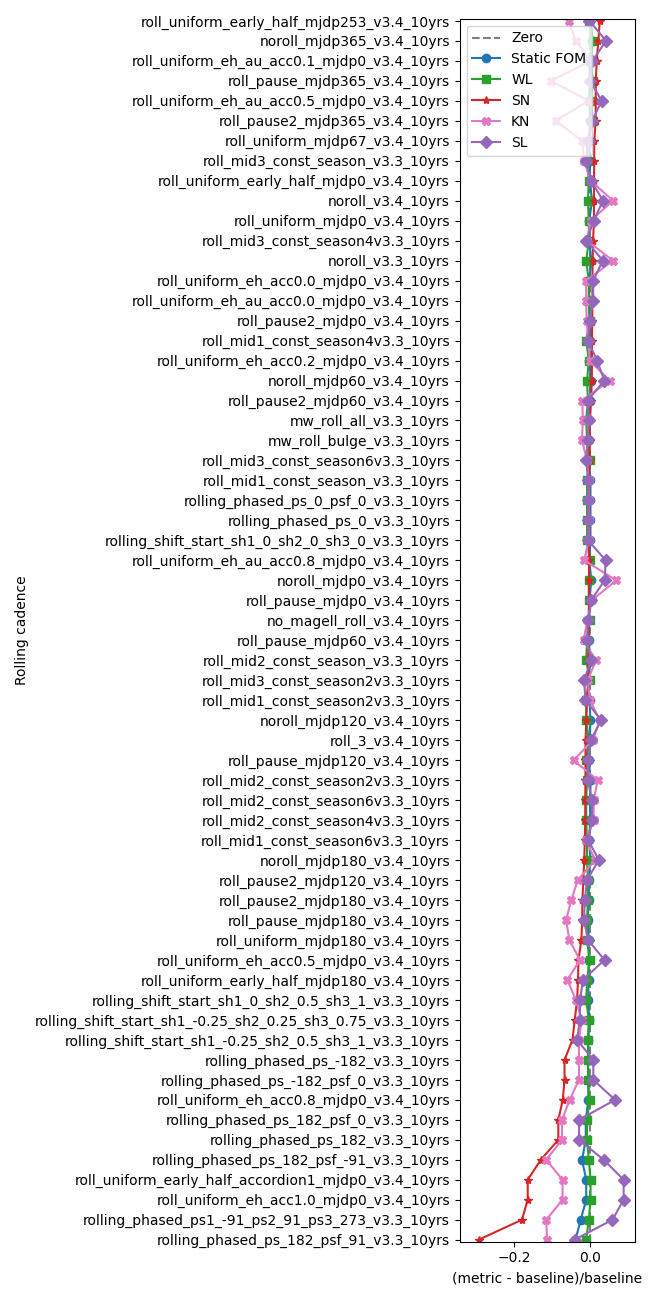

In [187]:
list_of_sims = list(maf_output.index[maf_output.index.str.contains('roll')])
list_of_sims.pop(list_of_sims.index('no_pairs_noroll_v3.4_10yrs')) # Causes such a big variation everything else is unreadable
# The SN metric tends to be the most sensitive so we order by that for readability
sn_metric = get_full_metric_name('sn', metric_names)
list_of_sims = maf_output_rel.loc[list_of_sims].sort_values(sn_metric).index

probes = ['fom', 'wl', 'sn', 'kn', 'sl']

plot_individual_sims(maf_output_rel, metric_names, list_of_sims, probes=probes, ylabel=y_label, 
                     xlabel = 'Rolling cadence', expand_ylim_by=[1.1, 1.1], figsize=(6.5,13), 
                     legend_outside=True, plot_vertical=True)
plt.gca().get_legend().set_visible(False)
plt.tight_layout()
plt.legend(['Zero', 'Static FOM', 'WL', 'SN', 'KN', 'SL'], loc='upper left')

### Target of opportunity

/tmp/ipykernel_6368/2191849380.py:80: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


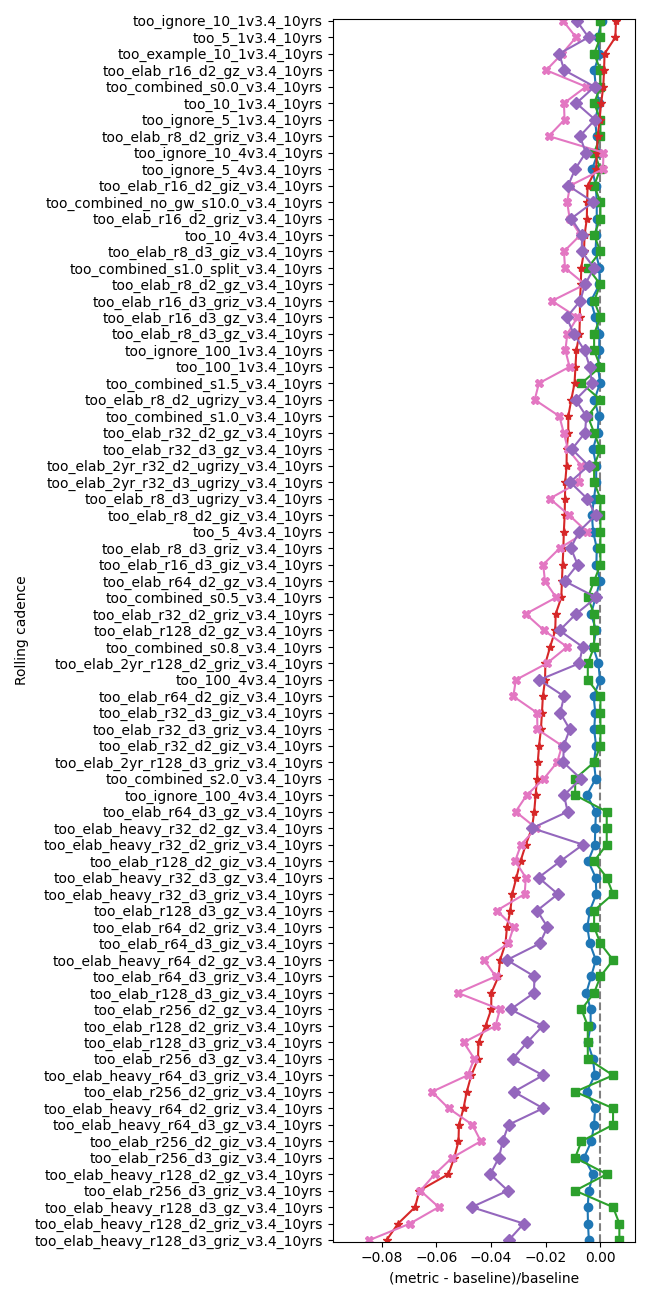

In [183]:
list_of_sims = list(maf_output.index[maf_output.index.str.contains('too')])
# The SN metric tends to be the most sensitive so we order by that for readability
sn_metric = get_full_metric_name('sn', metric_names)
list_of_sims = maf_output_rel.loc[list_of_sims].sort_values(sn_metric).index

probes = ['fom', 'wl', 'sn', 'kn', 'sl']

plot_individual_sims(maf_output_rel, metric_names, list_of_sims, probes=probes, ylabel=y_label, 
                     xlabel = 'Rolling cadence', expand_ylim_by=[1.1, 1.1], figsize=(6.5,13), 
                     legend_outside=True, plot_vertical=True)
plt.gca().get_legend().set_visible(False)
plt.tight_layout()
# plt.legend(['Zero', 'Static FOM', 'WL', 'SN', 'KN', 'SL'], loc='upper left')

### DDFs

/tmp/ipykernel_6368/2191849380.py:80: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


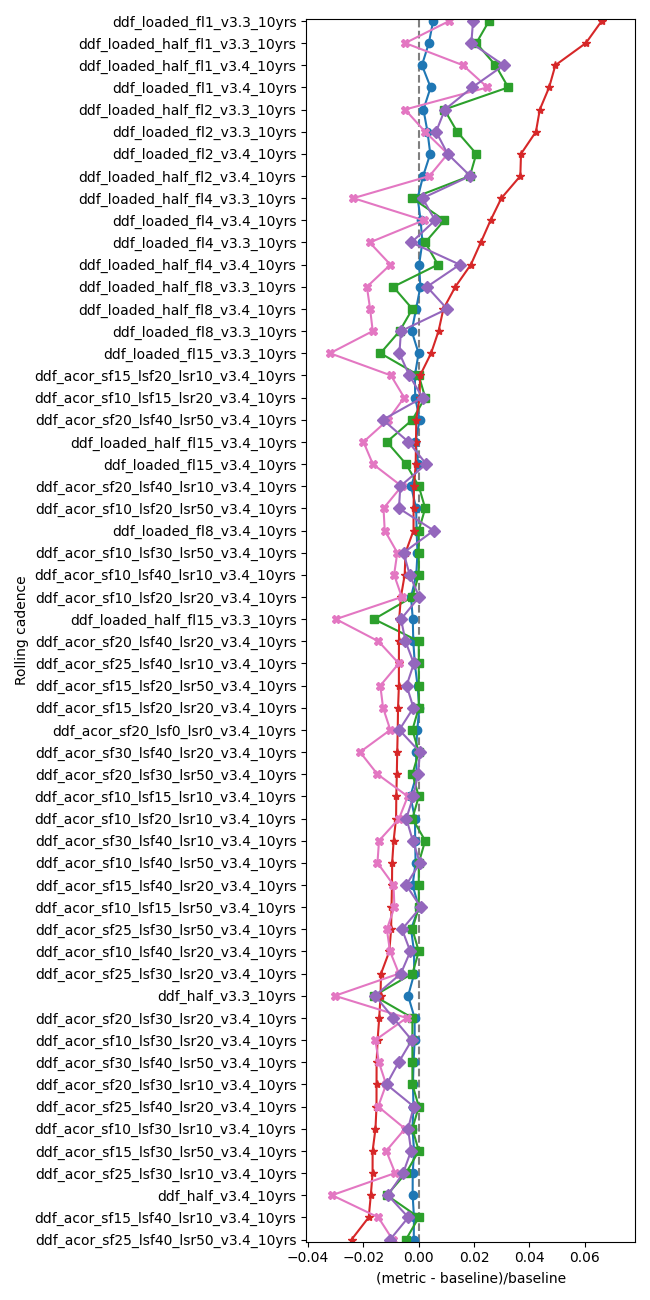

In [184]:
list_of_sims = list(maf_output.index[maf_output.index.str.contains('ddf')])
# The SN metric tends to be the most sensitive so we order by that for readability
sn_metric = get_full_metric_name('sn', metric_names)
list_of_sims = maf_output_rel.loc[list_of_sims].sort_values(sn_metric).index

probes = ['fom', 'wl', 'sn', 'kn', 'sl']

plot_individual_sims(maf_output_rel, metric_names, list_of_sims, probes=probes, ylabel=y_label, 
                     xlabel = 'Rolling cadence', expand_ylim_by=[1.1, 1.1], figsize=(6.5,13), 
                     legend_outside=True, plot_vertical=True)
plt.gca().get_legend().set_visible(False)
plt.tight_layout()
# plt.legend(['Zero', 'Static FOM', 'WL', 'SN', 'KN', 'SL'], loc='upper left')